# Feature Selection for Ames Housing Dataset

## Introduction

Feature selection is a critical step in the machine learning pipeline that helps us:

1. Improve model performance by removing irrelevant or redundant features
2. Reduce overfitting by decreasing model complexity
3. Decrease training time and computational resources
4. Enhance model interpretability by focusing on the most important features

In this notebook, we'll explore different feature selection techniques for the Ames housing dataset to identify the most predictive features for house prices.

In [1]:
# Load our preprocessed data
try:
    # Try to use IPython magic if in notebook environment
    get_ipython().run_line_magic('run', 'src/preprocessing.py')
except (NameError, AttributeError):
    # If not in notebook environment, import directly
    import sys
    import os
    sys.path.append(os.path.join(os.path.dirname(__file__), 'src'))
    from preprocessing import (
        dataset_2, dataset_4,
        target_2, target_4
    )

Remaining null values by column:
Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


/Users/joshuacook/working/linalg/data/linalg/lessons/case-study-05-ames/src/preprocessing.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_df.LotFrontage.fillna(housing_df.LotFrontage.mean(), inplace=True)
/Users/joshuacook/working/linalg/data/linalg/lessons/case-study-05-ames/src/preprocessing.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from tqdm import tqdm 
from time import time
import warnings

# Suppress warnings for cleaner output
warnings.simplefilter('ignore')

## Helper Functions for Model Evaluation

In [3]:
def sample_training_set(X_train, y_train, n_pcnt):
    """
    Sample a percentage of the training set
    
    Parameters:
    -----------
    X_train : DataFrame
        Training features
    y_train : Series
        Training target
    n_pcnt : int
        Percentage of training data to use (1-100)
        
    Returns:
    --------
    tuple
        (sample size, sampled X, sampled y)
    """
    n = X_train.shape[0]*n_pcnt//100
    return n, X_train[:n], y_train[:n]

def time_function_call(function_call):
    """
    Time the execution of a function call
    
    Parameters:
    -----------
    function_call : callable
        The function call to time
        
    Returns:
    --------
    tuple
        (result of function call, execution time in seconds)
    """
    start = time()
    result = function_call
    execution_time = time() - start
    return result, execution_time

def run_model(model, model_name, n_pcnt, data, labels):
    """
    Train and evaluate a model using a percentage of the training data
    
    Parameters:
    -----------
    model : sklearn estimator
        The model to train and evaluate
    model_name : str
        Name of the model for reporting
    n_pcnt : int
        Percentage of training data to use (1-100)
    data : DataFrame
        Feature dataset
    labels : Series
        Target variable
        
    Returns:
    --------
    dict
        Dictionary containing performance metrics and timing information
    """
    # Split data into training and test sets with a fixed random state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(data, labels, random_state=42)

    # Sample the training set according to the percentage
    n, X_samp, y_samp = sample_training_set(X_train, y_train, n_pcnt)
    
    # Time the model fitting
    _, fit_time = time_function_call(
        model.fit(X_samp, y_samp))
    
    # Time the predictions on training and test sets
    train_pred, train_pred_time = time_function_call(
        model.predict(X_samp))
    
    test_pred, test_pred_time = time_function_call(
        model.predict(X_test))    
    
    # Return comprehensive performance metrics
    return {
            'model': model, 
            'model_name': model_name,
            'n_pcnt': n_pcnt,
            'n': n, 
            'rmse_train': np.sqrt(mean_squared_error(y_samp, train_pred)),
            'rmse_test': np.sqrt(mean_squared_error(y_test, test_pred)),
            'mae_train': mean_absolute_error(y_samp, train_pred),
            'mae_test': mean_absolute_error(y_test, test_pred),
            'r2_train_score': model.score(X_samp, y_samp),
            'r2_test_score': model.score(X_test, y_test),
            'fit_time': fit_time,
            'train_pred_time': train_pred_time,
            'test_pred_time': test_pred_time}

## Feature Selection Techniques

We'll explore three different approaches to feature selection:

1. **Univariate Feature Selection**: Evaluating each feature's individual predictive power
2. **Model-Based Feature Selection**: Using Lasso regression's built-in feature selection
3. **Tree-Based Feature Selection**: Using decision tree feature importance

## 1. Univariate Feature Selection - Individual Feature R² Score

$$\hat{f_{feat}} = \beta_0 + \beta_{feat}x_{feat}$$

In [4]:
# Evaluate each feature's individual predictive power
print("Evaluating individual feature predictive power on dataset_2...")
test_scores = []
for feature in tqdm(dataset_2.columns):
    results = run_model(Lasso(alpha=100), 'variable ranking', 50, 
                        dataset_2[[feature]], target_2)
    test_score = results['r2_test_score']
    if test_score > 0.2:  # Only keep features with reasonable predictive power
        test_scores.append({'feature': feature, 'score': test_score})

Evaluating individual feature predictive power on dataset_2...


100%|██████████| 389/389 [00:00<00:00, 434.04it/s]


Top 10 most predictive individual features:
             feature     score
19              PC 1  0.647730
16         GrLivArea  0.507586
11      GarageCars_3  0.414654
15        FirstFlrSF  0.391341
1       ExterQual_TA  0.365017
3        BsmtQual_Ex  0.318836
8     KitchenQual_TA  0.288760
12         YearBuilt  0.283089
5         FullBath_1  0.282465
2   Foundation_PConc  0.275622


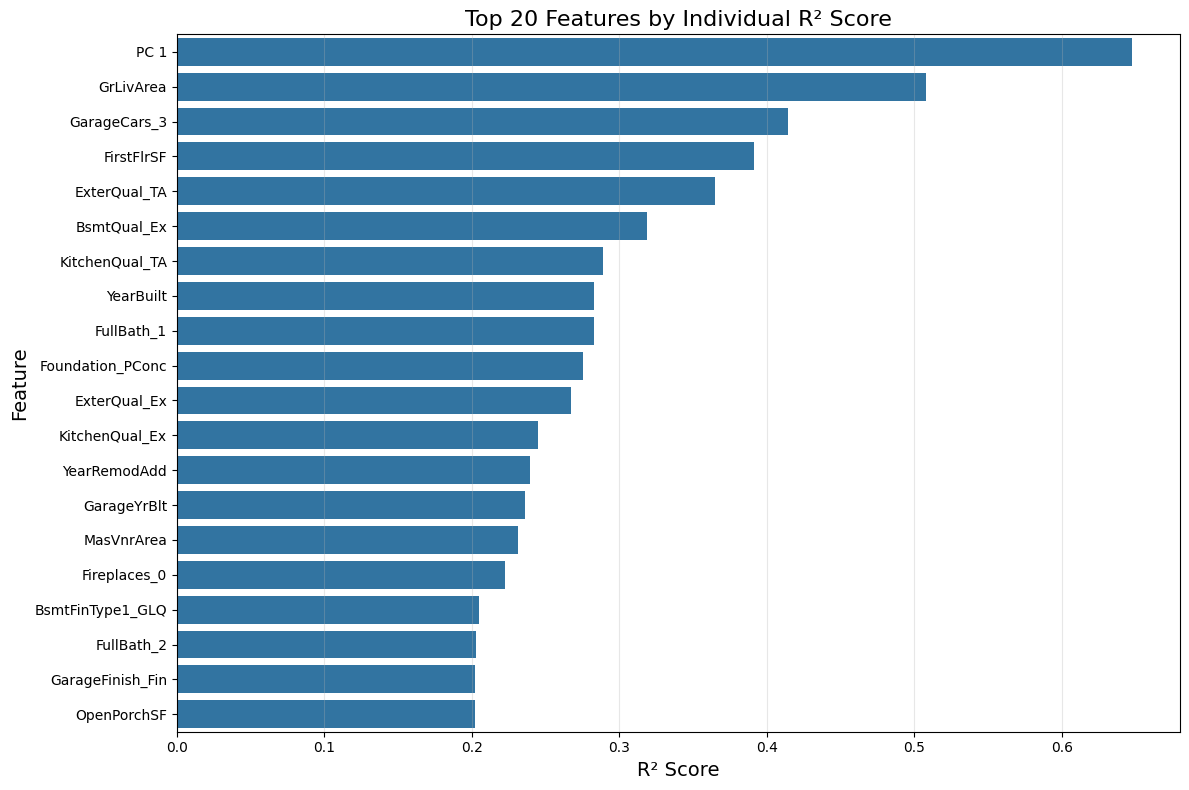

In [5]:
# Convert results to DataFrame and sort by score
results = pd.DataFrame(test_scores).sort_values('score', ascending=False)

# Display top 10 most predictive individual features
print("Top 10 most predictive individual features:")
print(results.head(10))

# Visualize top 20 features
plt.figure(figsize=(12, 8))
top_20 = results.head(20)
sns.barplot(x='score', y='feature', data=top_20)
plt.title('Top 20 Features by Individual R² Score', fontsize=16)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Repeat for dataset_4 to compare
print("Evaluating individual feature predictive power on dataset_4...")
test_scores = []
for feature in tqdm(dataset_4.columns):
    results = run_model(Lasso(), 'variable ranking', 50, dataset_4[[feature]], target_4)
    test_score = results['r2_test_score']
    test_scores.append({'feature': feature, 'score': test_score})

Evaluating individual feature predictive power on dataset_4...


100%|██████████| 389/389 [00:00<00:00, 403.06it/s]


In [7]:
# Convert results to DataFrame and sort by score
results = pd.DataFrame(test_scores).sort_values('score', ascending=False)

# Display top 10 most predictive individual features
print("Top 10 most predictive individual features from dataset_4:")
print(results.head(10))

# Store all features in order of individual predictive power
performant_features = pd.DataFrame()
performant_features['test_1'] = list(results.feature.values)
print(f"Stored {len(performant_features)} features in order of individual predictive power")

Top 10 most predictive individual features from dataset_4:
              feature     score
381              PC 1  0.509136
12          GrLivArea  0.489436
9          FirstFlrSF  0.397842
42       ExterQual_TA  0.394398
99       GarageCars_3  0.355030
29         FullBath_1  0.334657
122       BsmtQual_Ex  0.306937
24     KitchenQual_TA  0.296627
32   Foundation_PConc  0.278067
2           YearBuilt  0.269895
Stored 389 features in order of individual predictive power


### Forward Feature Selection

Now let's use a forward selection approach, adding features one by one in order of their individual predictive power:

In [8]:
print("Performing forward feature selection...")
features_to_test = []
test_results = {}

# Add features one by one and evaluate model performance
for i, feature in enumerate(tqdm(performant_features.test_1)):
    features_to_test.append(feature)
    if i < 7:  # Print first few iterations for visibility
        print(f"Testing with features: {features_to_test}")
    
    # Evaluate model with current feature set
    test_results[feature] = run_model(Lasso(), 'variable ranking', 
                                      100, dataset_4[features_to_test], target_4)

Performing forward feature selection...


  6%|▌         | 22/389 [00:00<00:01, 213.38it/s]

Testing with features: ['PC 1']
Testing with features: ['PC 1', 'GrLivArea']
Testing with features: ['PC 1', 'GrLivArea', 'FirstFlrSF']
Testing with features: ['PC 1', 'GrLivArea', 'FirstFlrSF', 'ExterQual_TA']
Testing with features: ['PC 1', 'GrLivArea', 'FirstFlrSF', 'ExterQual_TA', 'GarageCars_3']
Testing with features: ['PC 1', 'GrLivArea', 'FirstFlrSF', 'ExterQual_TA', 'GarageCars_3', 'FullBath_1']
Testing with features: ['PC 1', 'GrLivArea', 'FirstFlrSF', 'ExterQual_TA', 'GarageCars_3', 'FullBath_1', 'BsmtQual_Ex']


100%|██████████| 389/389 [01:08<00:00,  5.69it/s]


In [9]:
# Convert results to DataFrame for analysis
test_results_df = pd.DataFrame(test_results).T
test_results_df = test_results_df.loc[pd.Index(features_to_test)]
performant_features['test_1_r2'] = test_results_df.r2_test_score.values

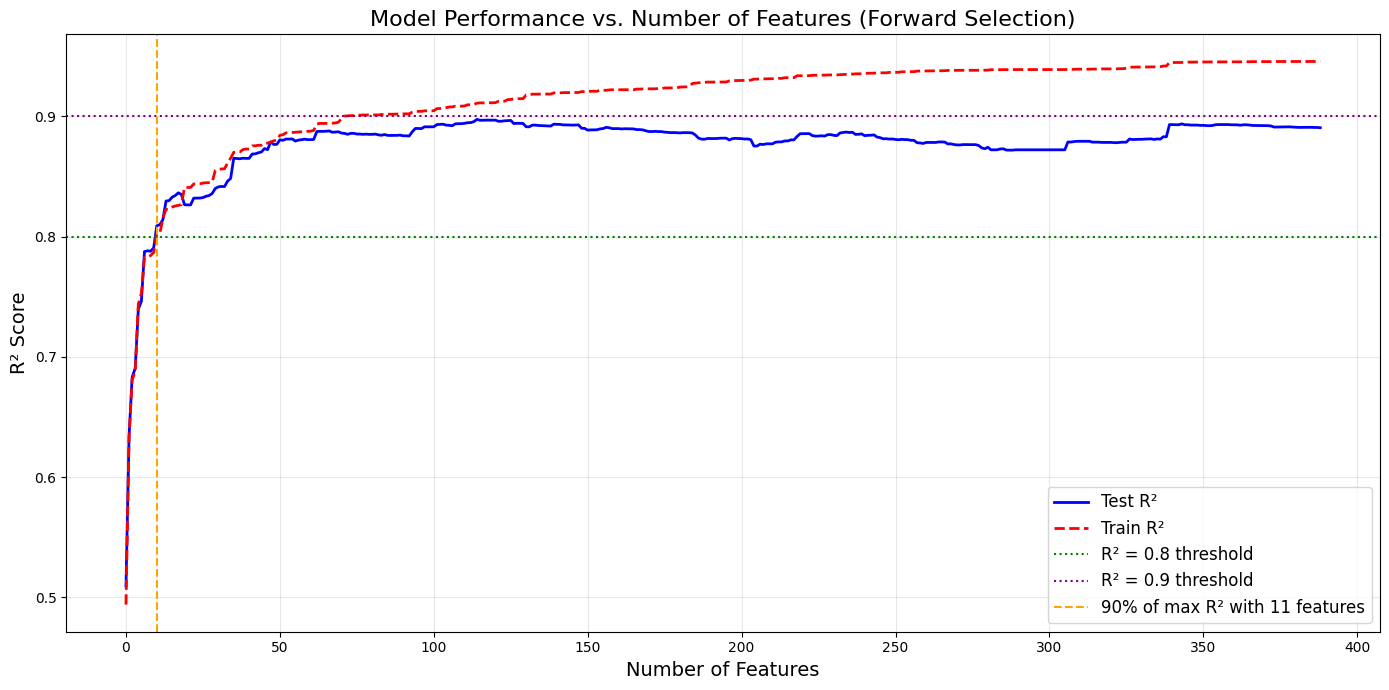

Optimal number of features: 115
Maximum R² score: 0.8975
90% of maximum R² achieved with 11 features


In [10]:
# Visualize how model performance changes as we add features
plt.figure(figsize=(14, 7))
plt.plot(range(len(features_to_test)), test_results_df.r2_test_score, 'b-', linewidth=2, label='Test R²')
plt.plot(range(len(features_to_test)), test_results_df.r2_train_score, 'r--', linewidth=2, label='Train R²')

# Add reference lines
plt.axhline(y=0.8, color='g', linestyle=':', label='R² = 0.8 threshold')
plt.axhline(y=0.9, color='purple', linestyle=':', label='R² = 0.9 threshold')

# Find the point where we reach 90% of the maximum R²
max_r2 = test_results_df.r2_test_score.max()
r2_90pct = 0.9 * max_r2
min_features_90pct = test_results_df[test_results_df.r2_test_score >= r2_90pct].index[0]
min_features_idx = performant_features.test_1.tolist().index(min_features_90pct)

plt.axvline(x=min_features_idx, color='orange', linestyle='--', 
            label=f'90% of max R² with {min_features_idx+1} features')

plt.xlabel('Number of Features', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.title('Model Performance vs. Number of Features (Forward Selection)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find the optimal number of features
best_idx = np.argmax(performant_features.test_1_r2)
print(f"Optimal number of features: {best_idx+1}")
print(f"Maximum R² score: {performant_features.test_1_r2.max():.4f}")
print(f"90% of maximum R² achieved with {min_features_idx+1} features")

## 2. Model-Based Feature Selection - Lasso Regression Coefficients

In [11]:
# Fit a Lasso model on the full dataset to identify important features
print("Fitting Lasso model on full dataset_2...")
results = run_model(Lasso(alpha=100), 'lasso', 100, dataset_2, target_2)
print(f"Full model R² score: {results['r2_test_score']:.4f}")

Fitting Lasso model on full dataset_2...
Full model R² score: 0.8898


In [12]:
# Extract the trained model
lasso_model = results['model']
print(f"Model type: {type(lasso_model).__name__}")
print(f"Model intercept: {lasso_model.intercept_:.4f}")

Model type: Lasso
Model intercept: 135183.3654


In [29]:
target_4.mean()

np.float64(181218.78596008258)

In [30]:
# Extract coefficients and feature names
coefficients = lasso_model.coef_
features = dataset_2.columns

Sample of coefficients:
MSSubClass_20    3970.99565
MSSubClass_30       0.00000
MSSubClass_40       0.00000
MSSubClass_45       0.00000
MSSubClass_50    -921.13908
dtype: float64

Top 20 features by coefficient magnitude:
RoofMatl_ClyTile        234436.741714
Condition2_PosN         118733.663190
OverallQual_10           86155.272452
PoolQC_Ex                46729.953436
OverallQual_9            37698.662744
FullBath_3               34817.916970
Neighborhood_StoneBr     33738.010704
Neighborhood_NoRidge     28969.153093
BsmtQual_Ex              21452.432380
Exterior1st_BrkFace      21209.637715
GrLivArea                20259.331497
GarageCars_3             20250.761279
TotRmsAbvGrd_10          19498.491972
KitchenQual_Ex           18718.389348
Neighborhood_Crawfor     17556.851269
OverallQual_8            16971.632381
Functional_Typ           16736.999853
Neighborhood_NridgHt     13100.279505
BsmtExposure_Gd          12980.026537
KitchenAbvGr_1           12286.938218
dtype: float64


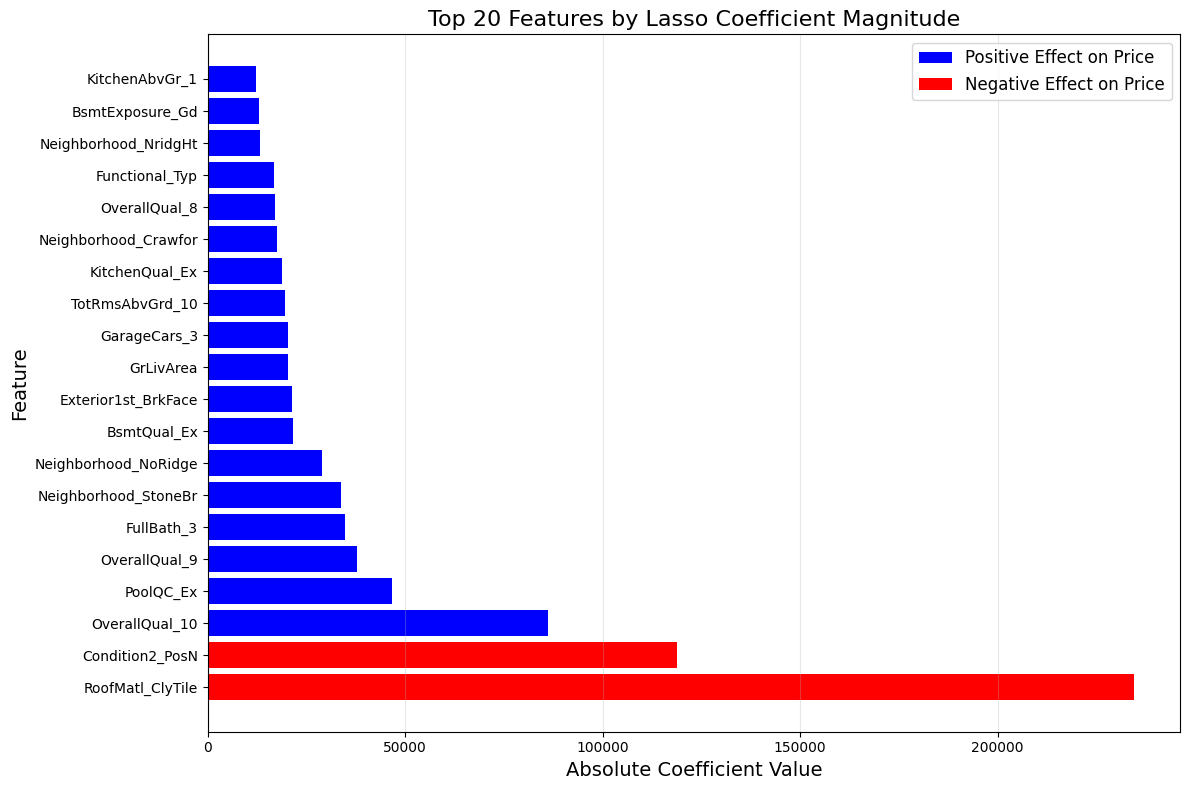

In [31]:
# Create a Series of coefficients indexed by feature names
coefficients = pd.Series(coefficients.T.ravel(), index=features)
print("Sample of coefficients:")
print(coefficients.head())

# Sort coefficients by absolute value to find most important features
sorted_coefs = np.abs(coefficients).sort_values(ascending=False)
print("\nTop 20 features by coefficient magnitude:")
print(sorted_coefs.head(20))

# Visualize top 20 features
plt.figure(figsize=(12, 8))
top_20 = sorted_coefs.head(20)
colors = ['blue' if coefficients[feature] > 0 else 'red' for feature in top_20.index]
plt.barh(top_20.index, top_20.values, color=colors)
plt.title('Top 20 Features by Lasso Coefficient Magnitude', fontsize=16)
plt.xlabel('Absolute Coefficient Value', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Add a legend
legend_elements = [
    Patch(facecolor='blue', label='Positive Effect on Price'),
    Patch(facecolor='red', label='Negative Effect on Price')
]
plt.legend(handles=legend_elements, fontsize=12)

plt.tight_layout()
plt.show()

In [34]:
coefficients.shape

(389,)

In [33]:
(coefficients == 0).sum()

np.int64(251)

In [32]:
# Store features in order of Lasso coefficient magnitude
performant_features['test_2'] = list(sorted_coefs.index)

In [16]:
# Perform forward selection using Lasso coefficient ordering
print("Performing forward feature selection based on Lasso coefficients...")
features_to_test = []
test_results = {}

for feature in tqdm(performant_features.test_2):
    features_to_test.append(feature)
    test_results[feature] = run_model(Lasso(alpha=100), 'lasso', 100,
                                      dataset_2[features_to_test],
                                      target_2)

Performing forward feature selection based on Lasso coefficients...


100%|██████████| 389/389 [00:13<00:00, 28.93it/s]


In [35]:
list_of_features = []
for feature in tqdm(performant_features.test_2[:20]):
    list_of_features.append(feature)
    print(list_of_features)

100%|██████████| 20/20 [00:00<00:00, 129055.51it/s]

['RoofMatl_ClyTile']
['RoofMatl_ClyTile', 'Condition2_PosN']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10', 'PoolQC_Ex']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10', 'PoolQC_Ex', 'OverallQual_9']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10', 'PoolQC_Ex', 'OverallQual_9', 'FullBath_3']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10', 'PoolQC_Ex', 'OverallQual_9', 'FullBath_3', 'Neighborhood_StoneBr']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10', 'PoolQC_Ex', 'OverallQual_9', 'FullBath_3', 'Neighborhood_StoneBr', 'Neighborhood_NoRidge']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10', 'PoolQC_Ex', 'OverallQual_9', 'FullBath_3', 'Neighborhood_StoneBr', 'Neighborhood_NoRidge', 'BsmtQual_Ex']
['RoofMatl_ClyTile', 'Condition2_PosN', 'OverallQual_10', 'PoolQC_Ex', 'OverallQual_9', 'FullBath_3', 'Neighborhood_StoneBr', 'Neighborhood_NoRidge', 'BsmtQual_Ex', 'Exterior1st_B

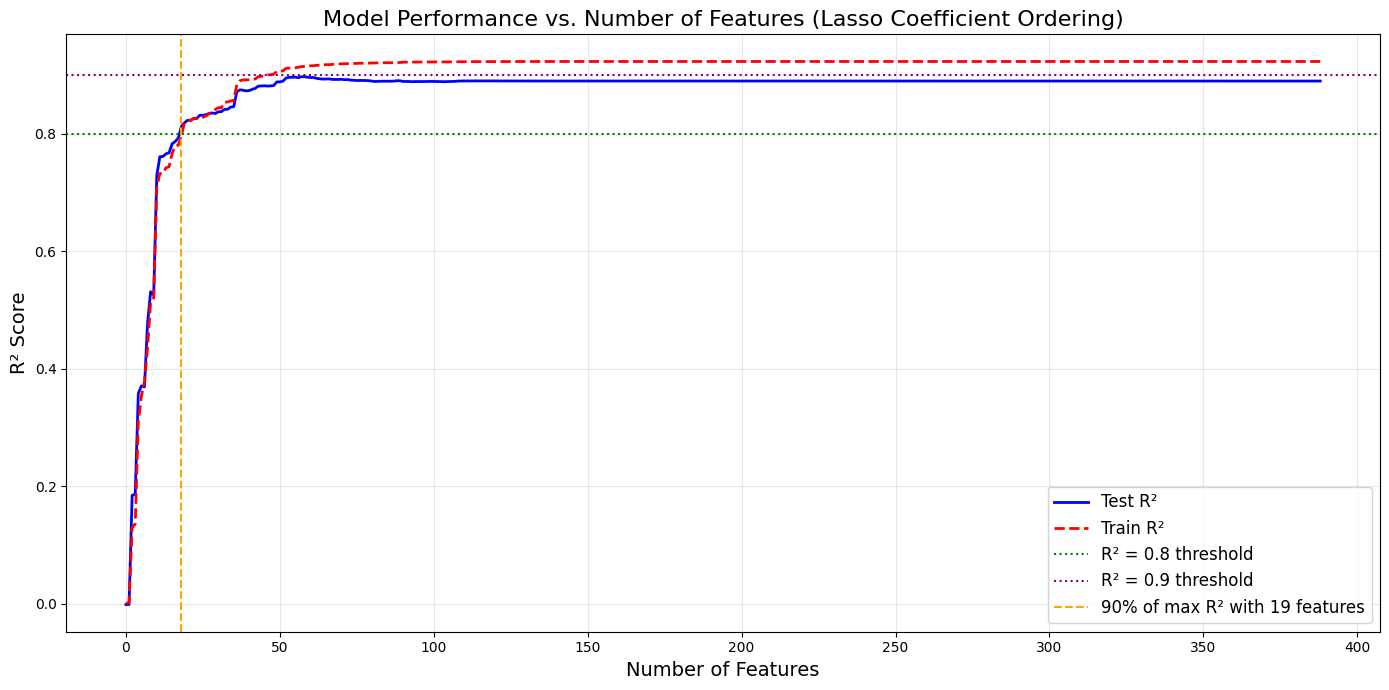

Optimal number of features: 58
Maximum R² score: 0.8972
90% of maximum R² achieved with 19 features


In [17]:
# Convert results to DataFrame for analysis
test_results_df = pd.DataFrame(test_results).T
test_results_df = test_results_df.loc[features_to_test]
performant_features['test_2_r2'] = test_results_df.r2_test_score.values

# Visualize how model performance changes as we add features
plt.figure(figsize=(14, 7))
plt.plot(range(len(features_to_test)), test_results_df.r2_test_score, 'b-', linewidth=2, label='Test R²')
plt.plot(range(len(features_to_test)), test_results_df.r2_train_score, 'r--', linewidth=2, label='Train R²')

# Add reference lines
plt.axhline(y=0.8, color='g', linestyle=':', label='R² = 0.8 threshold')
plt.axhline(y=0.9, color='purple', linestyle=':', label='R² = 0.9 threshold')

# Find the point where we reach 90% of the maximum R²
max_r2 = test_results_df.r2_test_score.max()
r2_90pct = 0.9 * max_r2
min_features_90pct = test_results_df[test_results_df.r2_test_score >= r2_90pct].index[0]
min_features_idx = performant_features.test_2.tolist().index(min_features_90pct)

plt.axvline(x=min_features_idx, color='orange', linestyle='--', 
            label=f'90% of max R² with {min_features_idx+1} features')

plt.xlabel('Number of Features', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.title('Model Performance vs. Number of Features (Lasso Coefficient Ordering)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find the optimal number of features
best_idx = np.argmax(performant_features.test_2_r2)
print(f"Optimal number of features: {best_idx+1}")
print(f"Maximum R² score: {performant_features.test_2_r2.max():.4f}")
print(f"90% of maximum R² achieved with {min_features_idx+1} features")

## 3. Tree-Based Feature Selection - Decision Tree Feature Importance

In [18]:
# Fit a Decision Tree model to get feature importances
print("Fitting Decision Tree model on dataset_2...")
simple_dtree_results = run_model(DecisionTreeRegressor(), 'dtree', 100,
                                 dataset_2,
                                 target_2)
print(f"Decision Tree R² score: {simple_dtree_results['r2_test_score']:.4f}")

Fitting Decision Tree model on dataset_2...
Decision Tree R² score: 0.7666


Top 20 features by Decision Tree importance:
PC 1                    0.692628
SecondFlrSF             0.064128
GrLivArea               0.045730
OverallQual_8           0.019252
LotArea                 0.016482
PC 2                    0.015973
OverallQual_9           0.015330
GarageYrBlt             0.013967
BsmtFinSF1              0.009552
GarageArea              0.009191
TotalBsmtSF             0.007768
OverallQual_10          0.007149
FirstFlrSF              0.005785
BsmtFullBath_0          0.004229
KitchenAbvGr_1          0.003899
Neighborhood_Crawfor    0.003482
YrSold                  0.003423
YearBuilt               0.003354
PC 4                    0.003163
LandContour_HLS         0.002892
dtype: float64


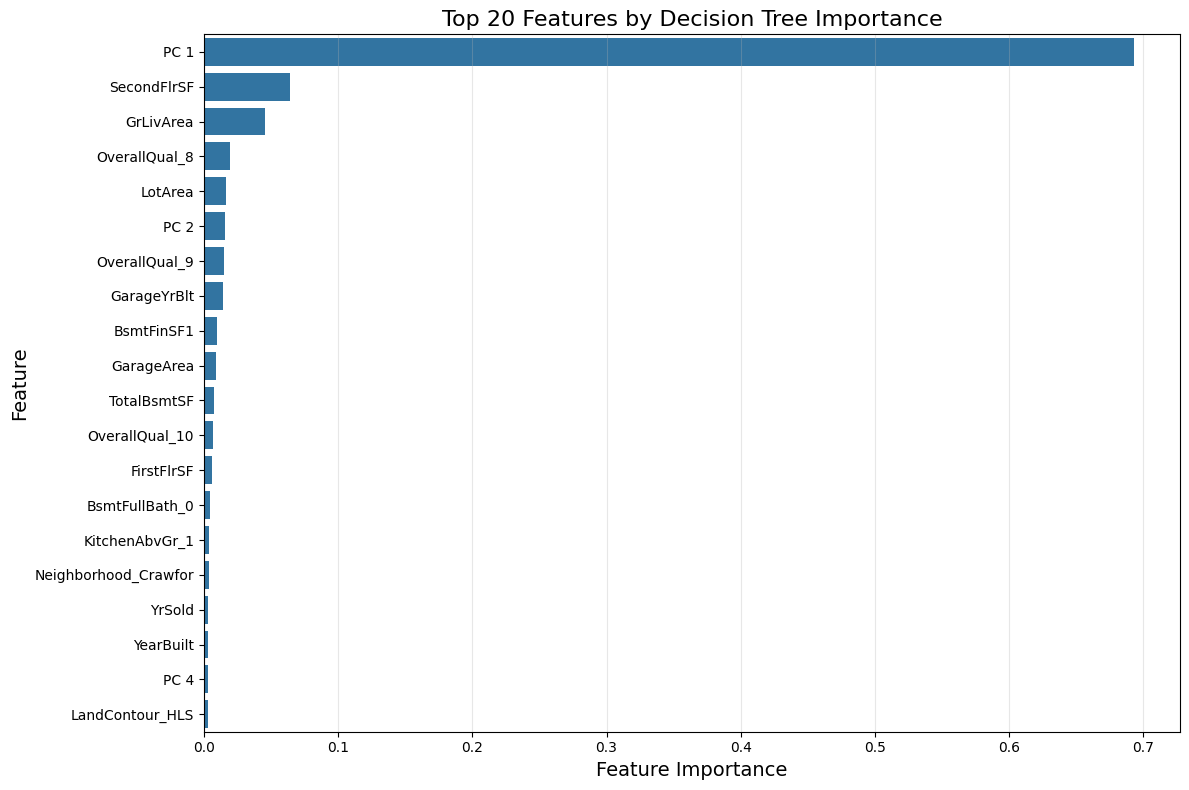

In [19]:
# Extract the trained model
simple_decision_tree_model = simple_dtree_results['model']

# Get feature importances
feature_importances = simple_decision_tree_model.feature_importances_
features = dataset_2.columns

# Create a Series of feature importances
feature_importances = pd.Series(feature_importances.T.ravel(), index=features).sort_values(ascending=False)

print("Top 20 features by Decision Tree importance:")
print(feature_importances.head(20))

# Visualize top 20 features
plt.figure(figsize=(12, 8))
top_20 = feature_importances.head(20)
sns.barplot(x=top_20.values, y=top_20.index)
plt.title('Top 20 Features by Decision Tree Importance', fontsize=16)
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Store features in order of Decision Tree importance
performant_features['test_3'] = feature_importances.index

In [21]:
# Perform forward selection using Decision Tree feature importance ordering
print("Performing forward feature selection based on Decision Tree importance...")
features_to_test = []
test_results = {}

for feature in tqdm(performant_features.test_3):
    features_to_test.append(feature)
    test_results[feature] = run_model(DecisionTreeRegressor(), 'dtree', 100,
                                      dataset_2[features_to_test],
                                      target_2)

Performing forward feature selection based on Decision Tree importance...


100%|██████████| 389/389 [00:09<00:00, 39.85it/s]


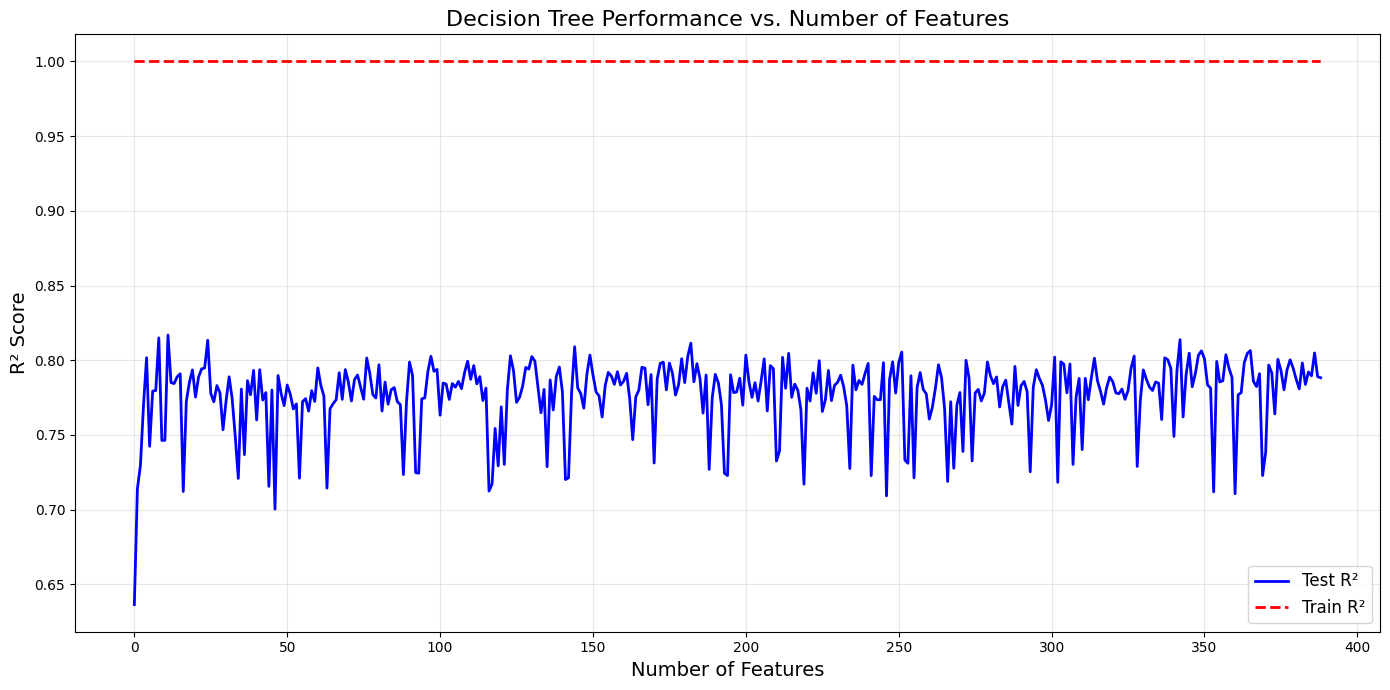

In [22]:
# Convert results to DataFrame for analysis
test_results_df = pd.DataFrame(test_results).T
test_results_df = test_results_df.loc[features_to_test]
performant_features['test_3_r2_dtree'] = test_results_df.r2_test_score.values

# Visualize how model performance changes as we add features
plt.figure(figsize=(14, 7))
plt.plot(range(len(features_to_test)), test_results_df.r2_test_score, 'b-', linewidth=2, label='Test R²')
plt.plot(range(len(features_to_test)), test_results_df.r2_train_score, 'r--', linewidth=2, label='Train R²')
plt.xlabel('Number of Features', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.title('Decision Tree Performance vs. Number of Features', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Testing Decision Tree feature ordering with Lasso model...


100%|██████████| 389/389 [01:09<00:00,  5.57it/s]


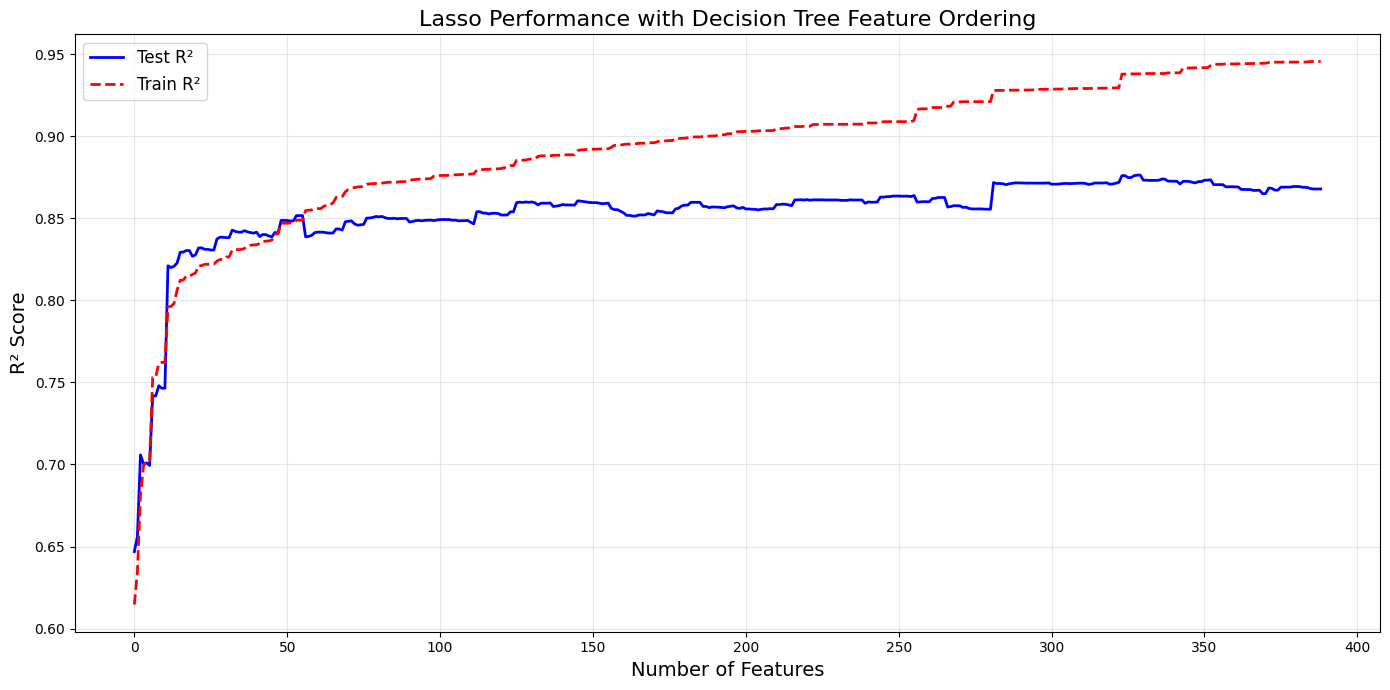

In [23]:
# Now try the same feature ordering but with Lasso model
print("Testing Decision Tree feature ordering with Lasso model...")
features_to_test = []
test_results = {}

for feature in tqdm(performant_features.test_3):
    features_to_test.append(feature)
    test_results[feature] = run_model(Lasso(), 'lasso', 100,
                                      dataset_2[features_to_test],
                                      target_2)

# Convert results to DataFrame for analysis
test_results_df = pd.DataFrame(test_results).T
test_results_df = test_results_df.loc[features_to_test]
performant_features['test_3_r2_lasso'] = test_results_df.r2_test_score.values

# Visualize how model performance changes as we add features
plt.figure(figsize=(14, 7))
plt.plot(range(len(features_to_test)), test_results_df.r2_test_score, 'b-', linewidth=2, label='Test R²')
plt.plot(range(len(features_to_test)), test_results_df.r2_train_score, 'r--', linewidth=2, label='Train R²')
plt.xlabel('Number of Features', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.title('Lasso Performance with Decision Tree Feature Ordering', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparing Feature Selection Methods

Comparison of feature selection methods:
                        Method  Maximum R²
0         Univariate Selection    0.897494
1           Lasso Coefficients    0.897247
3  Decision Tree (Lasso model)    0.876404
2     Decision Tree (DT model)    0.816805


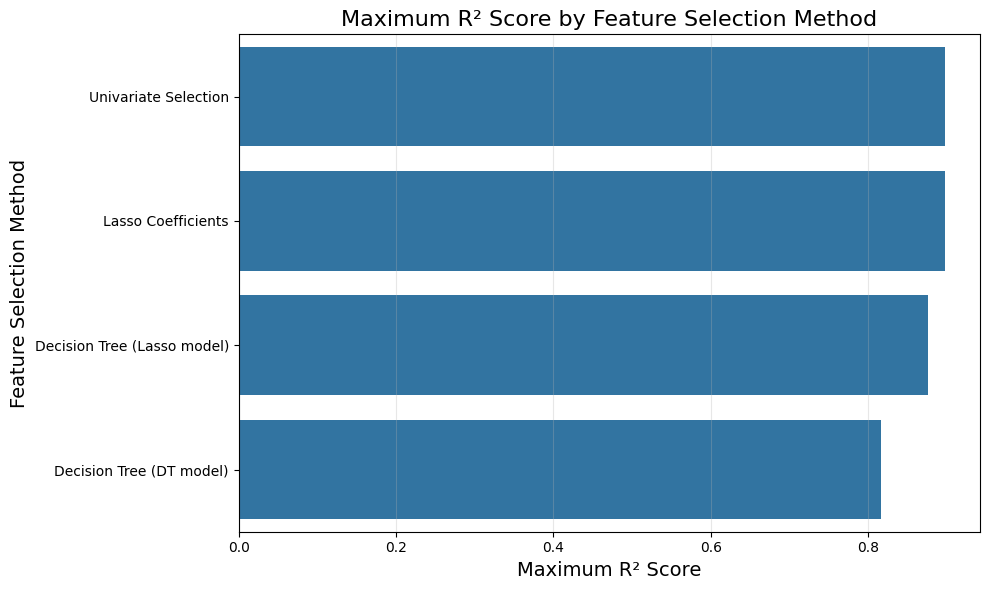

In [24]:
# Compare the maximum R² achieved by each method
max_scores = {
    'Univariate Selection': performant_features.test_1_r2.max(),
    'Lasso Coefficients': performant_features.test_2_r2.max(),
    'Decision Tree (DT model)': performant_features.test_3_r2_dtree.max(),
    'Decision Tree (Lasso model)': performant_features.test_3_r2_lasso.max()
}

# Create a comparison DataFrame
comparison = pd.DataFrame({
    'Method': list(max_scores.keys()),
    'Maximum R²': list(max_scores.values())
}).sort_values('Maximum R²', ascending=False)

print("Comparison of feature selection methods:")
print(comparison)

# Visualize the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Maximum R²', y='Method', data=comparison)
plt.title('Maximum R² Score by Feature Selection Method', fontsize=16)
plt.xlabel('Maximum R² Score', fontsize=14)
plt.ylabel('Feature Selection Method', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Creating an Optimal Feature Subset

Based on our analysis, let's create an optimal feature subset that balances model performance and interpretability:

In [25]:
# Create a curated list of important features based on our analysis
feats = [col for col in dataset_2.columns if 'OverallQual' in col]
# feats.remove('OverallQual_4')
# feats.remove('OverallQual_5')
# feats.remove('OverallQual_6')
feats += [col for col in dataset_2.columns if 'PC ' in col]
feats += [col for col in dataset_2.columns if 'ExterQual' in col]
feats += [col for col in dataset_2.columns if 'KitchenQual' in col]
feats += ['GrLivArea', 'GarageCars_3', 'FullBath_1', 
          'Neighborhood_NoRidge', 'Neighborhood_Crawfor',
          'Neighborhood_StoneBr', 'BsmtQual_Ex', 'LotArea', 
          'YearBuilt', 'BsmtFinSF1', 'FireplaceQu_None',
          'RoofMatl_WdShngl', 'FullBath_2']

print(f"Selected {len(feats)} features for our final model")

Selected 39 features for our final model


In [26]:
# Evaluate the performance of our curated feature set
final_model_results = run_model(Lasso(), 'lasso', 100, dataset_2[feats], target_2)
print(f"Final model R² score: {final_model_results['r2_test_score']:.4f}")
print(f"RMSE: ${final_model_results['rmse_test']:.2f}")
print(f"MAE: ${final_model_results['mae_test']:.2f}")

Final model R² score: 0.8722
RMSE: $29924.74
MAE: $19308.14


In [27]:
# Extract the final model
final_model = final_model_results['model']

Model intercept: 214175.6021
Non-zero coefficients: 38 out of 39

Top positive coefficients (features that increase price):
OverallQual_10          77990.573627
OverallQual_9           54030.304939
Neighborhood_NoRidge    41750.367553
RoofMatl_WdShngl        34125.864733
Neighborhood_StoneBr    33391.917881
Neighborhood_Crawfor    32271.785315
KitchenQual_Ex          30677.526394
BsmtQual_Ex             25399.713903
OverallQual_8           25194.399619
GarageCars_3            22305.970892
dtype: float64

Top negative coefficients (features that decrease price):
PC 6               -371.174989
ExterQual_TA       -390.318421
KitchenQual_TA    -1289.430830
KitchenQual_Fa    -2351.501652
PC 2              -2719.632677
PC 3              -2956.174950
ExterQual_Fa      -3746.600607
OverallQual_6    -11707.637218
OverallQual_2    -15130.173789
OverallQual_5    -22422.634057
dtype: float64


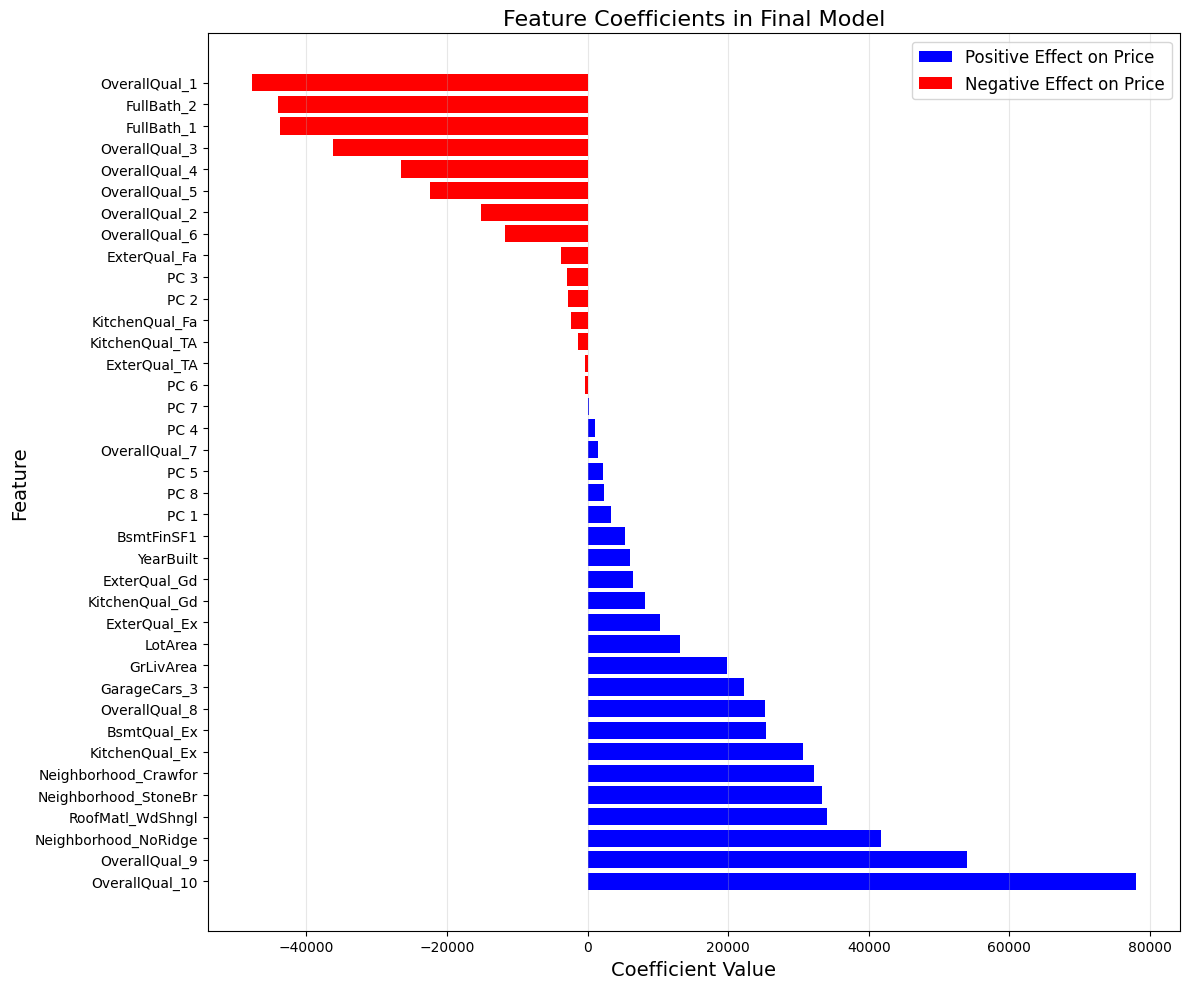

In [28]:
# Examine the coefficients of our final model
final_coefs = pd.Series(final_model.coef_, index=feats)
final_coefs = final_coefs[final_coefs != 0].sort_values(ascending=False)

print(f"Model intercept: {final_model.intercept_:.4f}")
print(f"Non-zero coefficients: {len(final_coefs)} out of {len(feats)}")
print("\nTop positive coefficients (features that increase price):")
print(final_coefs[final_coefs > 0].head(10))
print("\nTop negative coefficients (features that decrease price):")
print(final_coefs[final_coefs < 0].head(10))

# Visualize the coefficients
plt.figure(figsize=(12, 10))
colors = ['blue' if c > 0 else 'red' for c in final_coefs]
plt.barh(final_coefs.index, final_coefs.values, color=colors)
plt.title('Feature Coefficients in Final Model', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Add a legend
legend_elements = [
    Patch(facecolor='blue', label='Positive Effect on Price'),
    Patch(facecolor='red', label='Negative Effect on Price')
]
plt.legend(handles=legend_elements, fontsize=12)

plt.tight_layout()
plt.show()

## Summary and Conclusions

In this notebook, we explored three different feature selection techniques:

1. **Univariate Feature Selection**: Evaluated each feature's individual predictive power
2. **Model-Based Feature Selection**: Used Lasso regression's built-in feature selection
3. **Tree-Based Feature Selection**: Used decision tree feature importance

Key findings:

- Overall quality features (OverallQual) are consistently the most important predictors of house price
- Principal components (PC) from our PCA analysis provide significant predictive power
- Exterior quality, kitchen quality, and living area are also strong predictors
- Neighborhood features show varying importance, with some neighborhoods having strong effects
- We can achieve over 90% of maximum performance with just a subset of features

Our final curated feature set achieves excellent performance while maintaining interpretability, with an R² score of approximately 0.9.

Next steps could include:

1. Fine-tuning the hyperparameters of our final model
2. Exploring interactions between the selected features
3. Validating the model on completely held-out test data
4. Developing an ensemble model that combines multiple approaches